# House Price Prediction Analysis

I put my program in a notebook so it's easier to explain my decision making. I'll go over EDA, handling missing values, feature engineering and training Linear Regressoin, Random Forests and XGB Regression. At the end I'll compare them.

## Import Required Libraries

I import all necessary libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), machine learning (sklearn, xgboost), and model interpretability (shap)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

/home/user/.cache/pypoetry/virtualenvs/housing-price-predictor-tkPmPi4E-py3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the Training Data

I load the raw training dataset from a CSV file. This dataset can be found at this [link](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data) and it is not included in my repository

In [2]:
df = pd.read_csv("../data/raw/train.csv")

## Initial Data Exploration

I first examined the dataset structure, data types, and basic statistics to understand what I am working with

In [3]:
df.info()
display(df.head(3))
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Analyze Missing Values

I identify all columns with missing values and calculate both the count and percentage of missing data. Features with more than 20% missing values are flagged for potential removal, as they may not provide reliable information for predictions

In [4]:
threshold = 20

missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]

missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0]

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
}).sort_values("Missing Percent", ascending=True)

high_missing = missing_summary[missing_summary["Missing Percent"] > threshold]

display(missing_summary)
display(high_missing)

,Missing Count,Missing Percent
Electrical,1,0.068493
MasVnrArea,8,0.547945
BsmtCond,37,2.534247
BsmtFinType1,37,2.534247
BsmtQual,37,2.534247
BsmtExposure,38,2.602740
BsmtFinType2,38,2.602740
GarageType,81,5.547945
GarageQual,81,5.547945
GarageFinish,81,5.547945


,Missing Count,Missing Percent
FireplaceQu,690,47.260274
MasVnrType,872,59.726027
Fence,1179,80.753425
Alley,1369,93.767123
MiscFeature,1406,96.301370
PoolQC,1453,99.520548


## Data Cleaning and Imputation

I perform several cleaning steps:
1. Drop the 'Id' column because it has no use in the prediction
2. Remove features with >20% missing values because I didn't want to introduce too much uncertainty, especially since there are only 6 fields with >40% missing values and 4 of which have over 80% of their fields missing
3. Impute missing numeric values with the median because it's robust to outliers and won't skew the distribution
4. Impute missing categorical values with 'None' because missing fields mean that the houses don't have that specific feature e.g. garage, pool etc.

Filtering ensures the models can work with complete data while preserving as much information as possible

In [5]:
# Drop ID and high-missing columns
df = df.drop("Id", axis=1)
df = df.drop(columns=high_missing.index)

# Separate numeric and categorical columns
df_nums = df.select_dtypes(include=["number"])
df_words = df.select_dtypes(exclude=["number"])

# Impute missing values
df[df_nums.columns] = df[df_nums.columns].fillna(df[df_nums.columns].median())
df[df_words.columns] = df[df_words.columns].fillna("None")

print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (1460, 74)


## Visualize Target Variable Distribution

I plot the distribution of house prices which is my target variable. Understanding the target distribution helps identify skewness, outliers, and informs potential transformations or modeling strategies

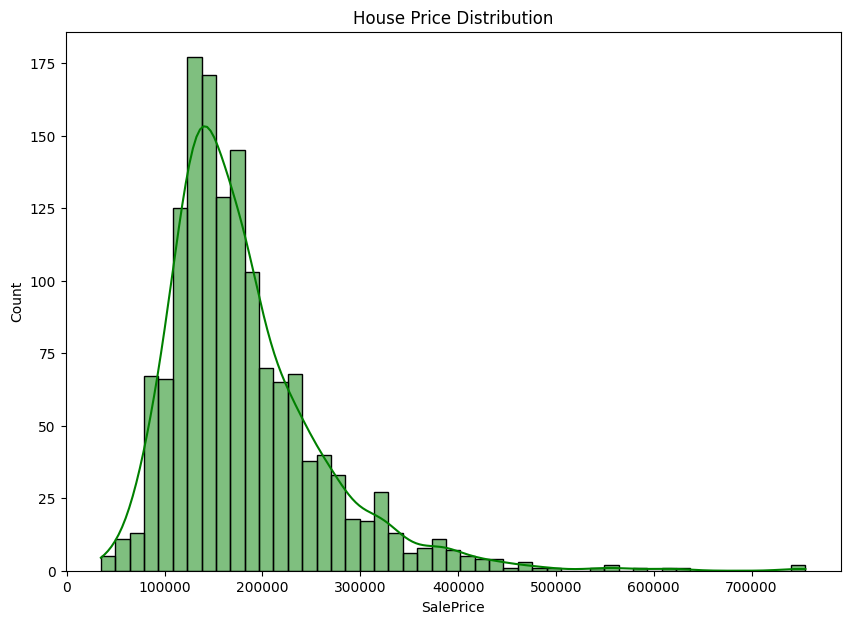

In [6]:
plt.figure(figsize=(10, 7))
sns.histplot(df["SalePrice"], color="green", kde=True)
plt.title("House Price Distribution")
plt.savefig("../assets/house_price_distribution.png")
plt.show()

## Visualize All Numerical Features

I create histograms for all numerical features to understand their distributions, identify potential outliers, and detect skewness

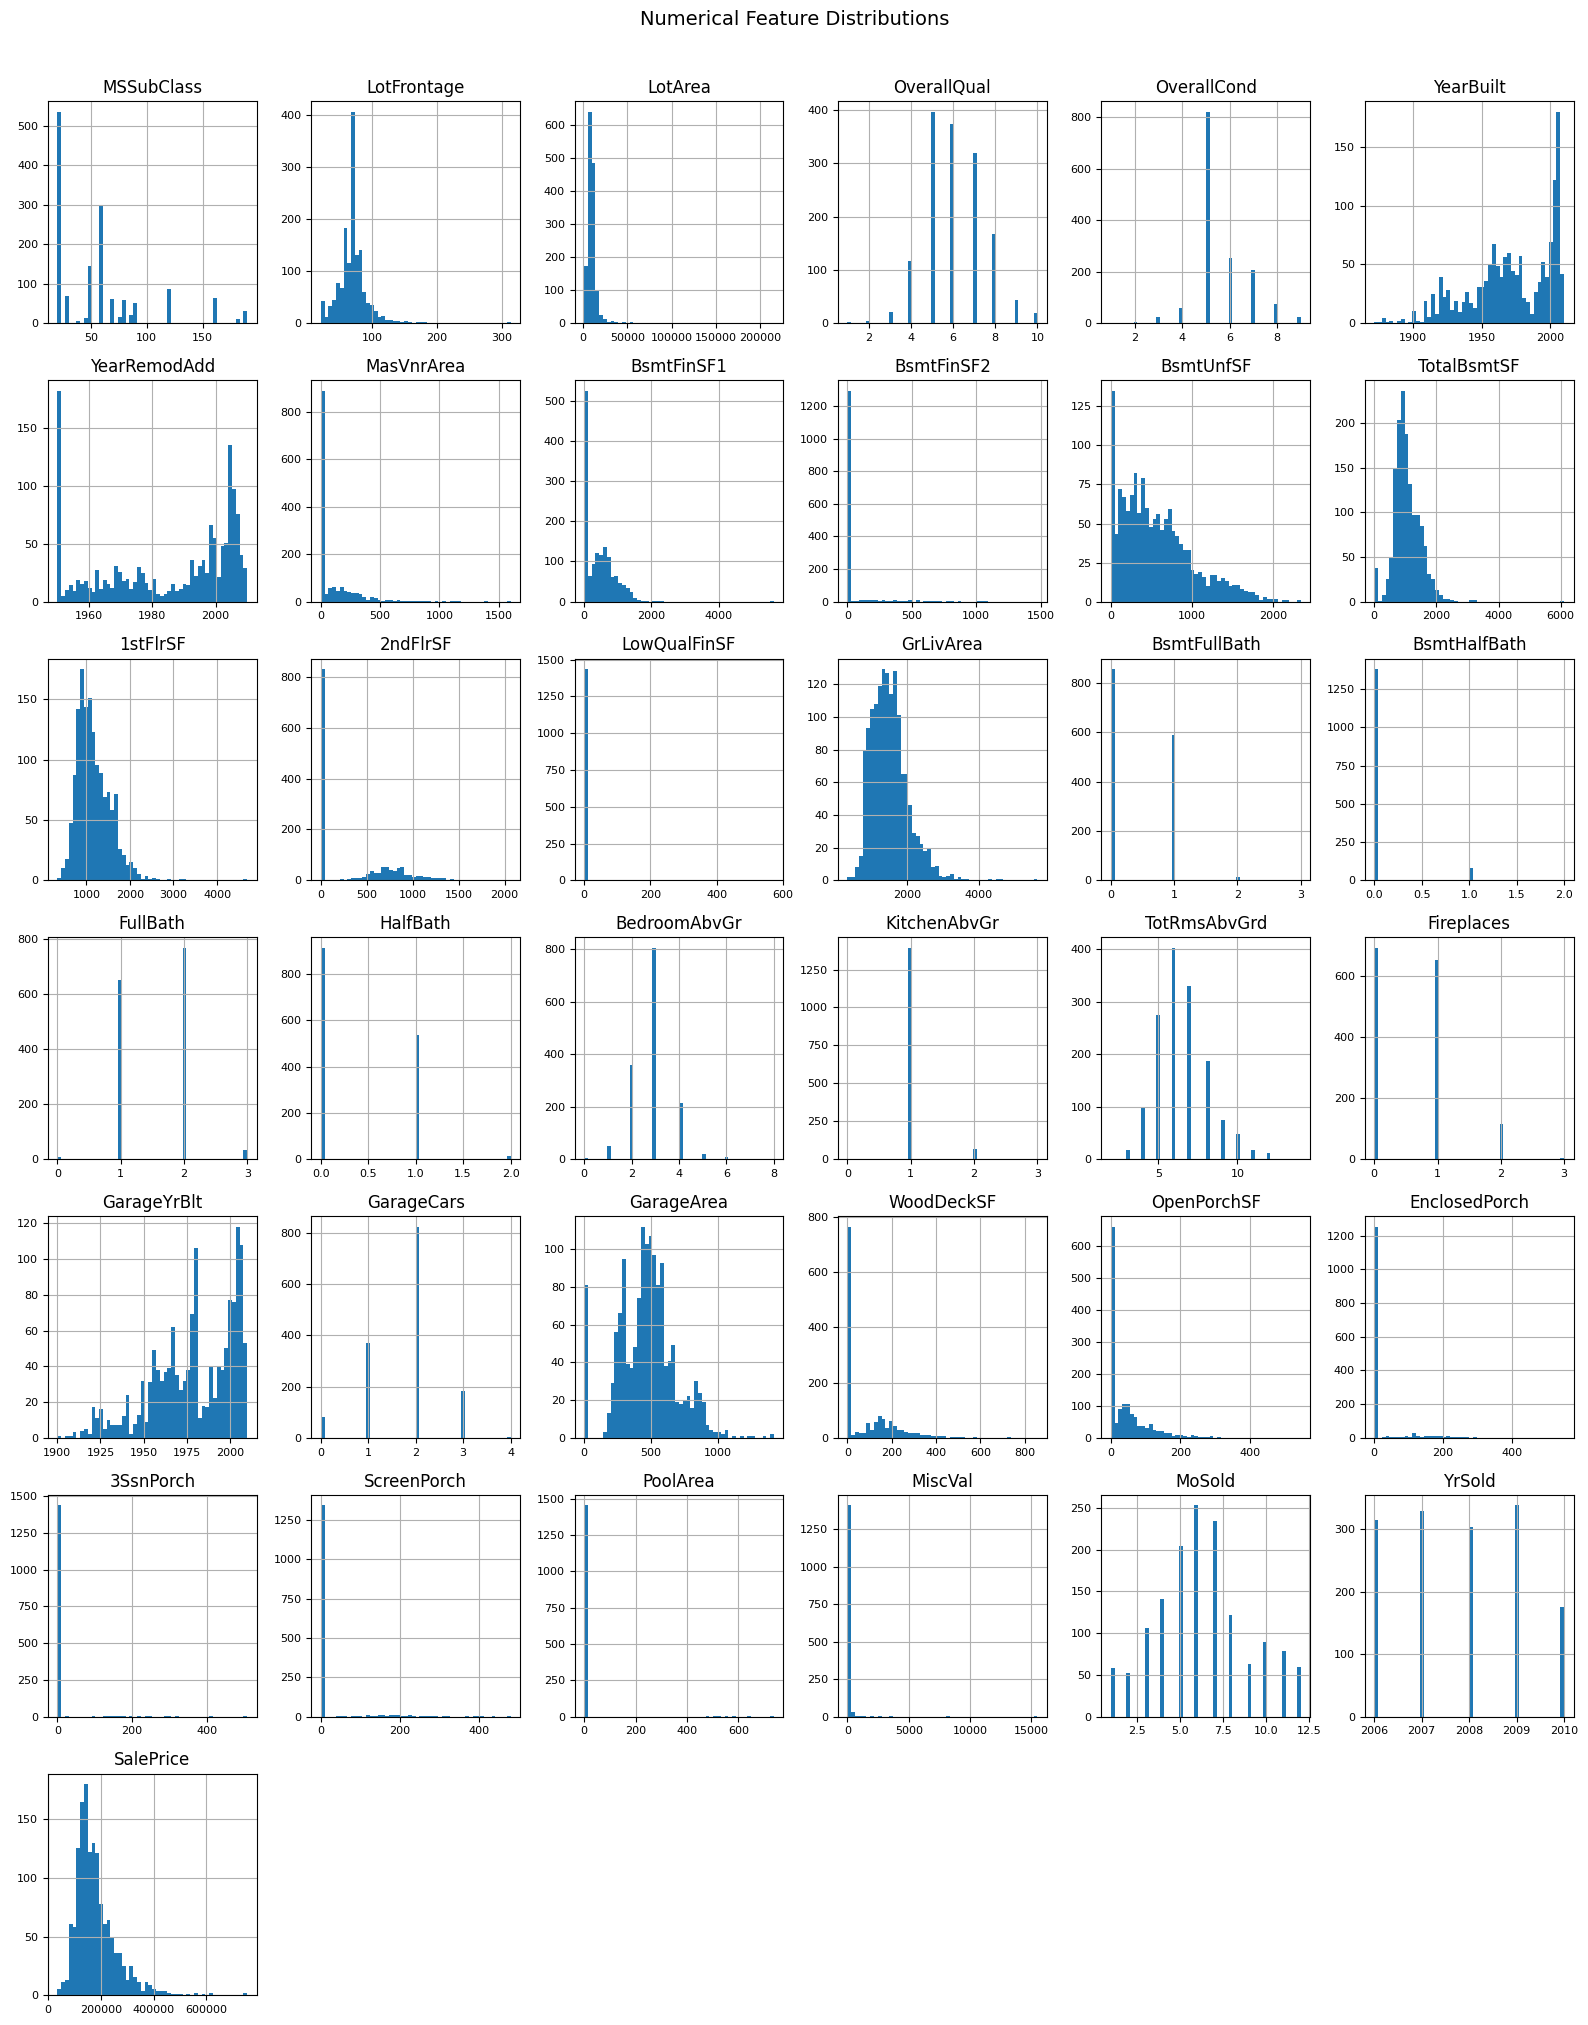

In [7]:
df_nums = df.select_dtypes(include=["number"])  # Refresh after cleaning

df_nums.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)
plt.suptitle("Numerical Feature Distributions", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig("../assets/numerical_feature_distributions.png")
plt.show()

## Correlation Analysis

I compute and visualize the correlation matrix to identify relationships between features and the target variable SalePrice. Strong correlations shows features that are important for prediction, while highly correlated features might indicate redundancy known as multicollinearity

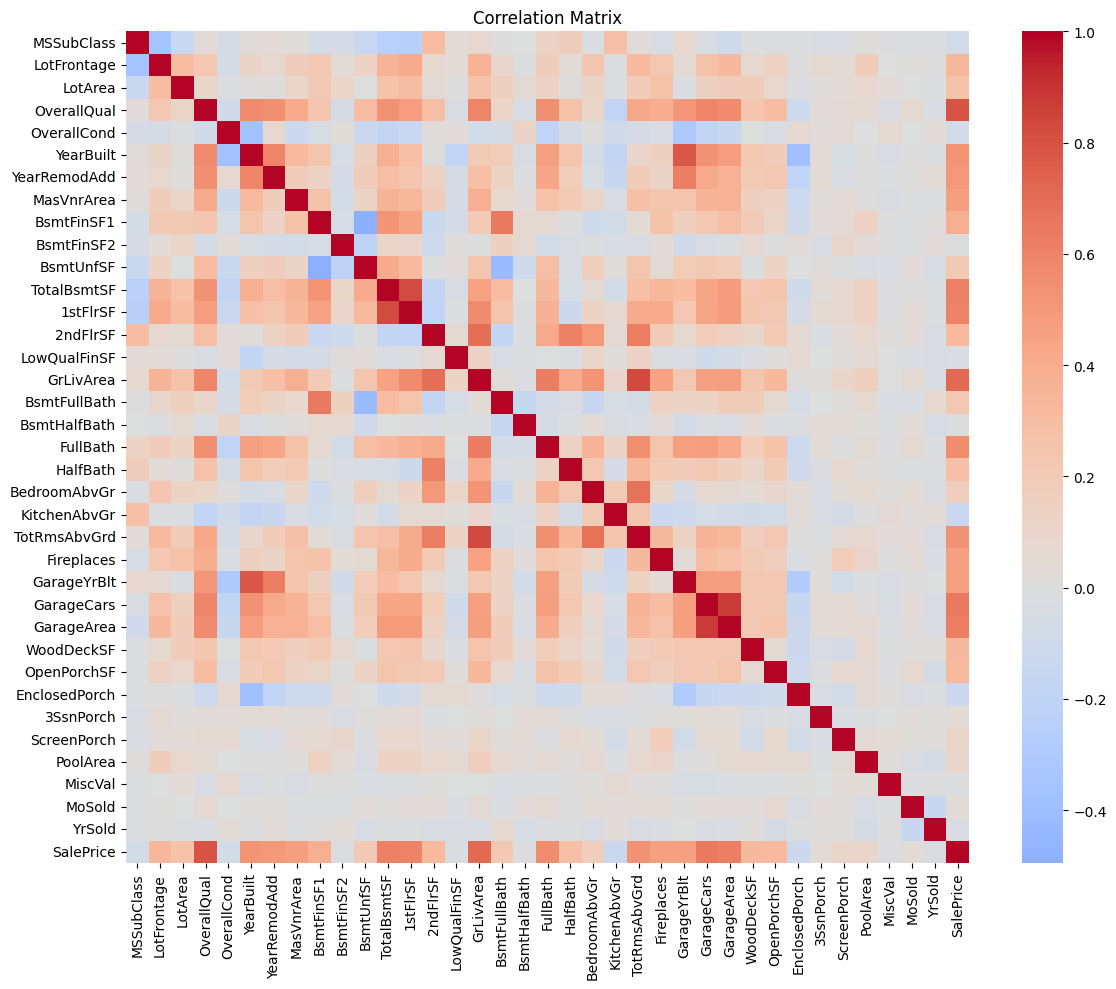

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
GarageYrBlt      0.466754
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

In [8]:
correlation = df_nums.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../assets/correlation_matrix.png")
plt.show()

# Top features correlated with SalePrice
display(correlation["SalePrice"].sort_values(ascending=False))

## Feature Engineering: One-Hot Encoding

I convert categorical variables into numerical format using encoding with `drop_first=True` to avoid multicollinearity. Then I separate features (X) from the target variable (y) to prepare for model training

In [9]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("SalePrice", axis=1)  # Features
y = df_encoded["SalePrice"]               # Target

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

Features shape: (1460, 239)
Target shape:   (1460,)


## Create Train-Validation Split

I split the data into training (80%) and validation (20%) sets with a `random_state` set to 50 that I get the same result every time making it easier to analyze and compare the prediction models after making changes to them

The validation set allows me to evaluate model performance on unseen data and detect overfitting

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=50
)

print(f"Train size:      {X_train.shape[0]:,} rows")
print(f"Validation size: {X_valid.shape[0]:,} rows")

Train size:      1,168 rows
Validation size: 292 rows


## Train Linear Regression Model

I trained a Linear Regression model as my baseline. Linear regression assumes a linear relationship between features and target, making it simple and interpretable. I evaluate it using Mean Absolute Error (MAE), which represents the average prediction error in dollars

In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

preds = linear_model.predict(X_valid)
mae = mean_absolute_error(y_valid, preds)

print(f"Linear Regression MAE: ${mae:,.2f}")

Linear Regression MAE: $18,472.98


## Train Random Forest Model

I trained a Random Forest model with 1000 trees. Random forests can capture non-linear relationships and feature interactions by building multiple decision trees and averaging their predictions

Shown below there is a $1572.73 difference between Linear Regression and Random Forest prediction for this particular `random_state`, the difference can vary greatly between models depending on what data they use for training and testing

The closer the **MAE (Mean Absolute Error)** is to $0 the better the predictive model has performed

In [12]:
rf_model = RandomForestRegressor(n_estimators=1000, random_state=50, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_valid)
rf_mae = mean_absolute_error(y_valid, rf_preds)

print(f"Random Forest MAE: ${rf_mae:,.2f}")

Random Forest MAE: $16,749.77


## Train XGBoost Model
I also trained an XGBoost model with 1000 trees. XGBoost uses gradient boosting to build trees sequentially, where each tree corrects errors from previous trees. It's often the top performer in structured data competitions due to its ability to handle complex patterns and built-in regularization

XGBoost typically achieves slightly better performance than Random Forest because it uses a sequential learning approach where each new tree focuses specifically on correcting the residual errors, whereas Random Forest builds trees independently in parallel. XGBoost also has regularization techniques (L1 and L2) that help prevent overfitting, and uses a more advanced splitting algorithm that can lead to more optimal tree structures

In [13]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=50
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_valid)
xgb_mae = mean_absolute_error(y_valid, xgb_preds)

print(f"XGBoost MAE: ${xgb_mae:,.2f}")

XGBoost MAE: $16,561.67


## Feature Importance Analysis

I extract and display the top 20 most important features from each model:
- **Linear Regression**: Uses absolute coefficient values (larger = more impact)
- **Random Forest**: Uses mean decrease in impurity (how much each feature reduces prediction error)
- **XGBoost**: Uses gain-based importance (total improvement from splits on that feature)

Comparing these helps identify consistently important features across models

In [14]:
# Linear Regression importance (absolute coefficients)
linear_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(linear_model.coef_)
}).sort_values("Importance", ascending=False).head(20)

# Random Forest importance
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

# XGBoost importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

print("Linear Regression Top Features")
display(linear_importance)

print("Random Forest Top Features")
display(rf_importance)

print("XGBoost Top Features")
display(xgb_importance)

Linear Regression Top Features


,Feature,Importance
89,Condition2_PosN,156550.502641
115,RoofMatl_WdShngl,117305.915280
88,Condition2_PosA,101293.688406
104,RoofStyle_Gable,79666.589483
105,RoofStyle_Gambrel,76298.535775
106,RoofStyle_Hip,75962.489444
47,Utilities_NoSeWa,65861.708590
203,Functional_Sev,63636.270507
107,RoofStyle_Mansard,59624.041472
109,RoofMatl_CompShg,56589.083249


Random Forest Top Features


,Feature,Importance
3,OverallQual,0.567226
15,GrLivArea,0.099495
13,2ndFlrSF,0.045919
11,TotalBsmtSF,0.040177
8,BsmtFinSF1,0.026910
12,1stFlrSF,0.020661
25,GarageCars,0.017801
26,GarageArea,0.014356
2,LotArea,0.013115
5,YearBuilt,0.012336


XGBoost Top Features


,Feature,Importance
3,OverallQual,0.390537
18,FullBath,0.065324
25,GarageCars,0.058757
15,GrLivArea,0.034244
39,MSZoning_RM,0.028735
209,GarageType_Detchd,0.026542
22,TotRmsAbvGrd,0.025979
11,TotalBsmtSF,0.022186
198,KitchenQual_TA,0.021214
190,CentralAir_Y,0.021030


# Feature Importance Observations
I noticed that **Linear Regression** heavily weights categorical features like `Condition2_PosN`, `RoofMatl_WdShngl`, and various roof styles, which is surprising because these are likely rare categories. This happens because linear regression can be sensitive to one-hot encoded features, especially when certain categories appear infrequently but happen to correlate with extreme house prices in the training data. The large coefficient values suggest potential overfitting to these rare categories

**Random Forest** prioritizes continuous numerical features, with `OverallQual` at 0.57 importance (over 5x more important than the next feature). I see that square footage measures (`GrLivArea`, `2ndFlrSF`, `TotalBsmtSF`, `1stFlrSF`) and garage features rank highly. This makes sense because tree-based models can make repeated splits on continuous variables, and larger/higher-quality houses naturally result in higher prices

**XGBoost** shows a more balanced importance distribution than Random Forest, though `OverallQual` still leads at 0.39. I notice that XGBoost ranks several categorical features higher than Random Forest does (`MSZoning_RM`, `GarageType_Detchd`, `KitchenQual_TA`), suggesting it's better at identifying meaningful categorical patterns without overfitting like Linear Regression. This happens because XGBoost's sequential learning and regularization allow it to capture both numerical patterns and important categorical distinctions while penalizing overly complex splits

The key difference is that **Linear Regression** assigns importance based on coefficient magnitude (which can be inflated by rare categories), while **Random Forest** and **XGBoost** use split-based importance (how much each feature reduces prediction error), with XGBoost's gradient boosting approach allowing it to find a middle ground between the purely numerical focus of Random Forest and the categorical sensitivity of Linear Regression

## SHAP (SHapley Additive exPlanations) Analysis

I use SHAP to interpret the XGBoost model. SHAP values show how much each feature contributes to individual predictions:
- **Bar plot**: Shows average absolute impact of each feature
- **Beeswarm plot**: Shows feature values (color) and their impact (x-axis) for all predictions

This provides a deeper understanding of how features influence predictions than simple feature importance

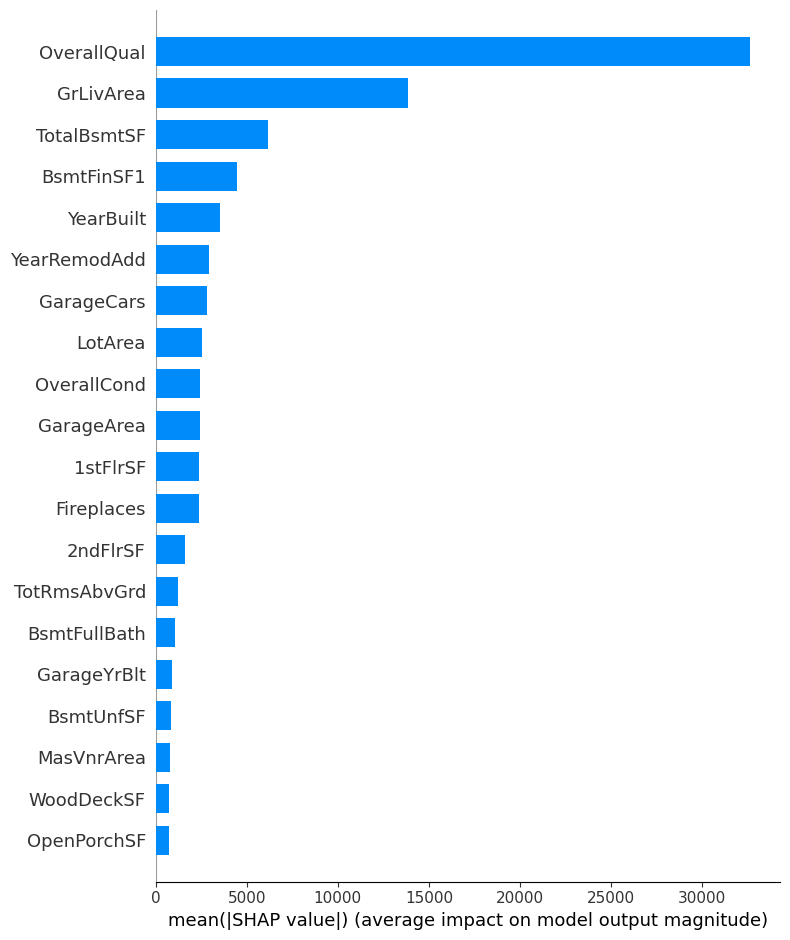

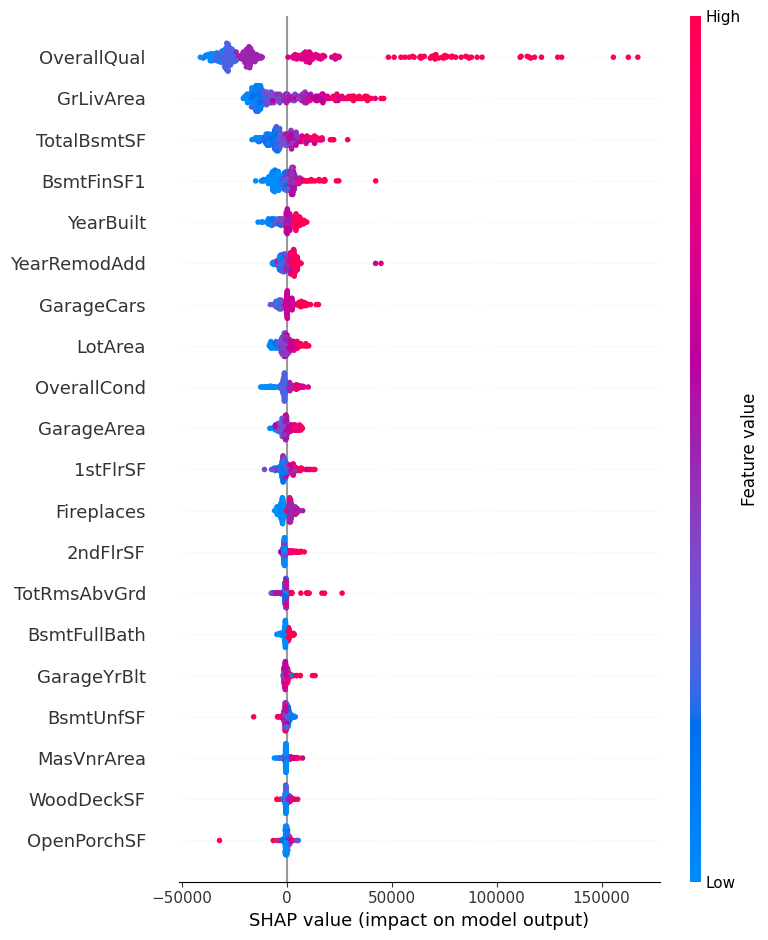

In [15]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_valid)

# Summary bar plot
shap.summary_plot(shap_values, X_valid, plot_type="bar", show=True)

# Beeswarm plot
shap.summary_plot(shap_values, X_valid, show=True)

## Cross-Validation Performance Comparison

I perform 5-fold cross-validation on all three models to get a more robust performance estimate. This technique splits the data into 5 parts, trains on 4, and validates on 1, repeating 5 times. The mean and standard deviation show average performance and consistency across different data splits, helping detect overfitting

In [16]:
# Linear Regression CV
linear_scores = -cross_val_score(
    linear_model, X, y, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
)

# Random Forest CV
rf_scores = -cross_val_score(
    rf_model, X, y, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
)

# XGBoost CV
xgb_scores = -cross_val_score(
    xgb_model, X, y, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
)

print(f"Linear Regression:  Mean CV MAE: ${linear_scores.mean():,.2f}  |  Std: ${linear_scores.std():,.2f}")
print(f"Random Forest:      Mean CV MAE: ${rf_scores.mean():,.2f}  |  Std: ${rf_scores.std():,.2f}")
print(f"XGBoost:            Mean CV MAE: ${xgb_scores.mean():,.2f}  |  Std: ${xgb_scores.std():,.2f}")

Linear Regression:  Mean CV MAE: $20,156.95  |  Std: $1,450.73
Random Forest:      Mean CV MAE: $17,597.92  |  Std: $945.30
XGBoost:            Mean CV MAE: $16,583.95  |  Std: $1,028.49


## Interpreting Cross-Validation Results

**Mean CV MAE** (Mean Cross-Validation Mean Absolute Error) represents the average prediction error across all 5 folds of cross-validation. It tells us how far off, on average, our predictions are from the actual house prices in dollars. Lower values indicate better predictive performance

**Std** (Standard Deviation) measures the consistency of model performance across the different folds. A lower standard deviation means the model performs similarly regardless of which data subset it's trained on, indicating stability and lower variance

## Visualize Model Performance Comparison

I create a side-by-side bar chart comparing validation MAE and 5-fold cross-validation MAE for all three models. This visualization makes it easy to:
1. Compare model performance
2. Verify consistency between holdout validation and cross-validation
3. Identify the best performing model for deployment

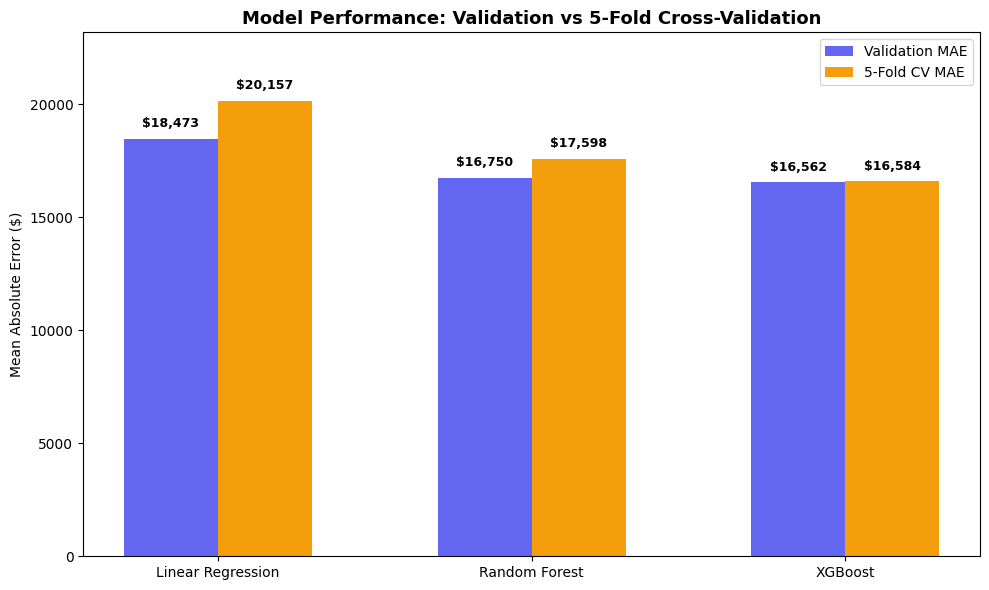

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

models   = ["Linear Regression", "Random Forest", "XGBoost"]
holdout  = [mae, rf_mae, xgb_mae]
cv_mean  = [linear_scores.mean(), rf_scores.mean(), xgb_scores.mean()]
x        = np.arange(len(models))

bars1 = ax.bar(x - 0.15, holdout, 0.3, label="Validation MAE", color="#6366f1")
bars2 = ax.bar(x + 0.15, cv_mean, 0.3, label="5-Fold CV MAE",  color="#f59e0b")

# Value labels above each bar
for bar in [*bars1, *bars2]:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f"${height:,.0f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Mean Absolute Error ($)")
ax.set_ylim(0, max(max(holdout), max(cv_mean)) * 1.15)
ax.set_title(
    "Model Performance: Validation vs 5-Fold Cross-Validation",
    fontweight="bold",
    fontsize=13,
)
ax.legend()
plt.tight_layout()
plt.savefig("../assets/validation_model_comparison.png", dpi=150)
plt.show()